In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

## Ajustando a base

In [100]:
print('hello')

hello


In [101]:
df = pd.read_csv('credit_risk_dataset.csv')
print(df.shape)
df.head()

(32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [102]:
variable_mapping = {
    'person_age': 'idade_individuo',
    'person_income': 'renda_anual_individuo',
    'person_home_ownership': 'tipo_posse_imovel',
    'person_emp_length': 'tempo_emprego_anos',
    'loan_intent': 'proposito_emprestimo',
    'loan_grade': 'classificacao_emprestimo',
    'loan_amnt': 'valor_emprestimo',
    'loan_int_rate': 'taxa_juros_emprestimo',
    'loan_status': 'status_emprestimo',
    'loan_percent_income': 'percentual_renda_emprestimo',
    'cb_person_default_on_file': 'historico_inadimplencia',
    'cb_person_cred_hist_length': 'duracao_historico_credito'
}
df.rename(columns=variable_mapping, inplace=True)
variable_mapping


{'person_age': 'idade_individuo',
 'person_income': 'renda_anual_individuo',
 'person_home_ownership': 'tipo_posse_imovel',
 'person_emp_length': 'tempo_emprego_anos',
 'loan_intent': 'proposito_emprestimo',
 'loan_grade': 'classificacao_emprestimo',
 'loan_amnt': 'valor_emprestimo',
 'loan_int_rate': 'taxa_juros_emprestimo',
 'loan_status': 'status_emprestimo',
 'loan_percent_income': 'percentual_renda_emprestimo',
 'cb_person_default_on_file': 'historico_inadimplencia',
 'cb_person_cred_hist_length': 'duracao_historico_credito'}

In [103]:
# Traduzindo e substituindo as categorias da variável tipo_posse_imovel
mapeamento_categorias_imovel = {
    'RENT': 'aluguel',
    'OWN': 'imovel_proprio',
    'MORTGAGE': 'imovel_financiado',
    'OTHER': 'imovel_outros'
}

df['tipo_posse_imovel'] = df['tipo_posse_imovel'].replace(mapeamento_categorias_imovel)

In [104]:
df['tipo_posse_imovel'].value_counts()

tipo_posse_imovel
aluguel              16446
imovel_financiado    13444
imovel_proprio        2584
imovel_outros          107
Name: count, dtype: int64

In [105]:
# Traduzindo e substituindo as categorias da variável proposito_emprestimo
mapeamento_categorias_proposito = {
    'DEBTCONSOLIDATION': 'fins_consolidacao_debito',
    'EDUCATION': 'fins_educacao',
    'MEDICAL': 'fins_medicos',
    'PERSONAL': 'fins_pessoais',
    'VENTURE': 'fins_negocios',
    'HOMEIMPROVEMENT': 'fins_reformas'
}



df['proposito_emprestimo'] = df['proposito_emprestimo'].replace(mapeamento_categorias_proposito)
df['proposito_emprestimo'].value_counts()

proposito_emprestimo
fins_educacao               6453
fins_medicos                6071
fins_negocios               5719
fins_pessoais               5521
fins_consolidacao_debito    5212
fins_reformas               3605
Name: count, dtype: int64

In [106]:
dict_hist = {
    'N': 'N',
    'Y': 'S'
}

print(df['historico_inadimplencia'].value_counts())
df['historico_inadimplencia'] = df['historico_inadimplencia'].replace(dict_hist)
print(df['historico_inadimplencia'].value_counts())

historico_inadimplencia
N    26836
Y     5745
Name: count, dtype: int64
historico_inadimplencia
N    26836
S     5745
Name: count, dtype: int64


In [107]:
df.head()

,idade_individuo,renda_anual_individuo,tipo_posse_imovel,tempo_emprego_anos,proposito_emprestimo,classificacao_emprestimo,valor_emprestimo,taxa_juros_emprestimo,status_emprestimo,percentual_renda_emprestimo,historico_inadimplencia,duracao_historico_credito
0,22,59000,aluguel,123.0,fins_pessoais,D,35000,16.02,1,0.59,S,3
1,21,9600,imovel_proprio,5.0,fins_educacao,B,1000,11.14,0,0.10,N,2
2,25,9600,imovel_financiado,1.0,fins_medicos,C,5500,12.87,1,0.57,N,3
3,23,65500,aluguel,4.0,fins_medicos,C,35000,15.23,1,0.53,N,2
4,24,54400,aluguel,8.0,fins_medicos,C,35000,14.27,1,0.55,S,4


## Analise Exploratoria de Dados

In [108]:
df = df.reset_index()
df.rename(columns={'index': 'id'}, inplace=True)
df.head()

,id,idade_individuo,renda_anual_individuo,tipo_posse_imovel,tempo_emprego_anos,proposito_emprestimo,classificacao_emprestimo,valor_emprestimo,taxa_juros_emprestimo,status_emprestimo,percentual_renda_emprestimo,historico_inadimplencia,duracao_historico_credito
0,0,22,59000,aluguel,123.0,fins_pessoais,D,35000,16.02,1,0.59,S,3
1,1,21,9600,imovel_proprio,5.0,fins_educacao,B,1000,11.14,0,0.10,N,2
2,2,25,9600,imovel_financiado,1.0,fins_medicos,C,5500,12.87,1,0.57,N,3
3,3,23,65500,aluguel,4.0,fins_medicos,C,35000,15.23,1,0.53,N,2
4,4,24,54400,aluguel,8.0,fins_medicos,C,35000,14.27,1,0.55,S,4


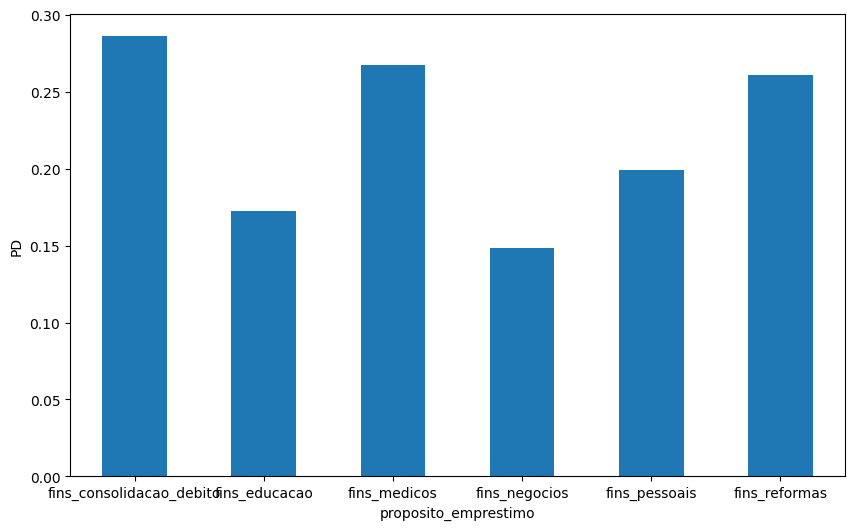

In [109]:
df_agp = df.groupby('proposito_emprestimo').agg({'status_emprestimo': 'sum', 'id': 'count'})
df_agp['perc_default'] =  df_agp['status_emprestimo'] / df_agp['id']
df_agp = df_agp.reset_index()

ax = df_agp.plot(x='proposito_emprestimo', 
                 y='perc_default', 
                 kind='bar',
                 figsize=(10,6), 
                 legend=False)
ax.set_ylabel('PD')
ax.tick_params(axis='x', rotation=0)
plt.show()

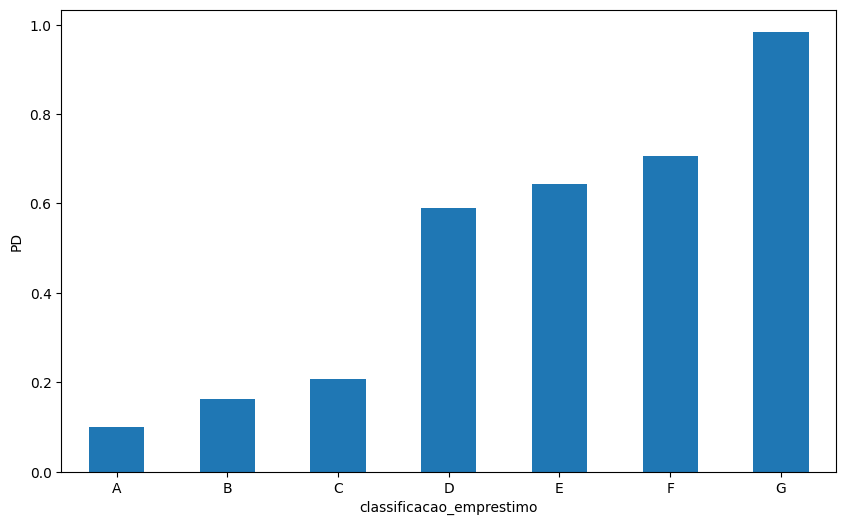

In [110]:
df_agp = df.groupby('classificacao_emprestimo').agg({'status_emprestimo': 'sum', 'id': 'count'})
df_agp['perc_default'] =  df_agp['status_emprestimo'] / df_agp['id']
df_agp = df_agp.reset_index()

ax = df_agp.plot(x='classificacao_emprestimo', 
                 y='perc_default', 
                 kind='bar',
                 figsize=(10,6), 
                 legend=False)
ax.set_ylabel('PD')
ax.tick_params(axis='x', rotation=0)
plt.show()

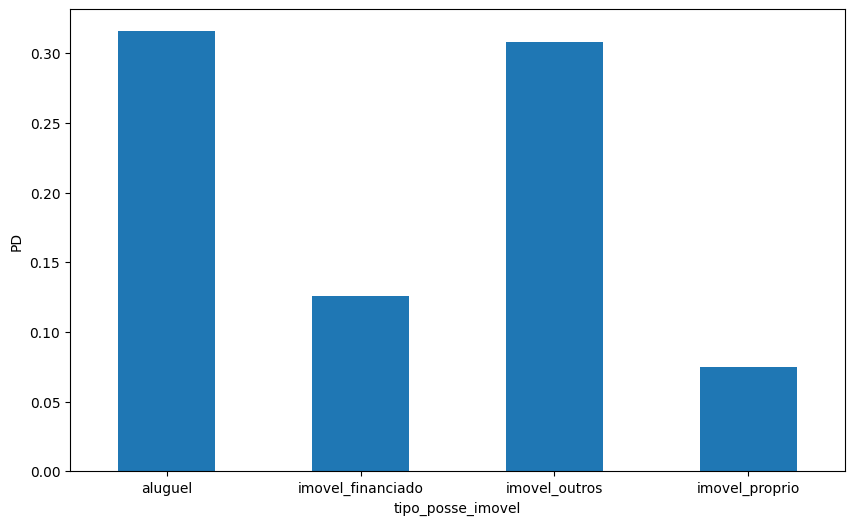

In [111]:
df_agp = df.groupby('tipo_posse_imovel').agg({'status_emprestimo': 'sum', 'id': 'count'})
df_agp['perc_default'] =  df_agp['status_emprestimo'] / df_agp['id']
df_agp = df_agp.reset_index()

ax = df_agp.plot(x='tipo_posse_imovel', 
                 y='perc_default', 
                 kind='bar',
                 figsize=(10,6), 
                 legend=False)
ax.set_ylabel('PD')
ax.tick_params(axis='x', rotation=0)
plt.show()

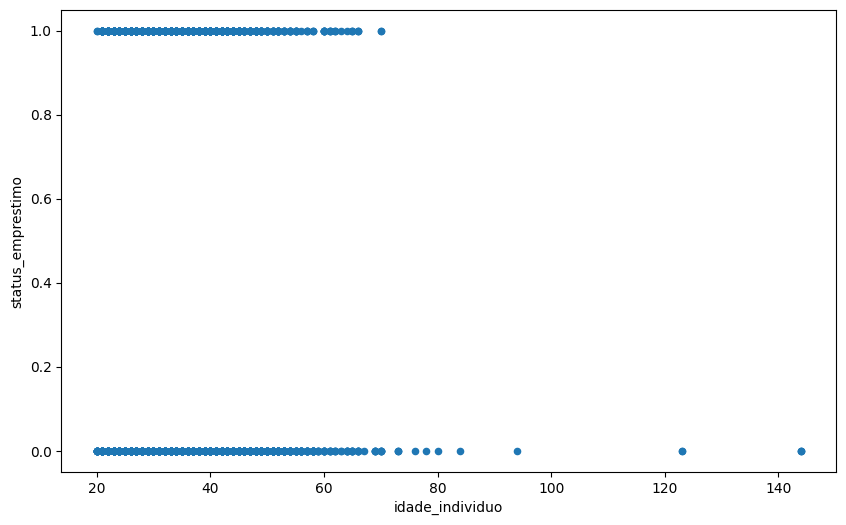

In [112]:
ax = df.plot(x='idade_individuo', 
            y='status_emprestimo', 
            figsize=(10,6), 
            kind='scatter',
            legend=False)
#ax.set_ylabel('PD')
#ax.tick_params(axis='x', rotation=0)
plt.show()

In [113]:
df.head(1)

,id,idade_individuo,renda_anual_individuo,tipo_posse_imovel,tempo_emprego_anos,proposito_emprestimo,classificacao_emprestimo,valor_emprestimo,taxa_juros_emprestimo,status_emprestimo,percentual_renda_emprestimo,historico_inadimplencia,duracao_historico_credito
0,0,22,59000,aluguel,123.0,fins_pessoais,D,35000,16.02,1,0.59,S,3


In [114]:
# Como está a correlação com variável resposta? 
colunas_quantitativas = ['status_emprestimo', 'idade_individuo', 'renda_anual_individuo', 'tempo_emprego_anos', 
                         'valor_emprestimo', 'taxa_juros_emprestimo', 'percentual_renda_emprestimo',
                         'duracao_historico_credito']
df[colunas_quantitativas].corr(method='pearson')

,status_emprestimo,idade_individuo,renda_anual_individuo,tempo_emprego_anos,valor_emprestimo,taxa_juros_emprestimo,percentual_renda_emprestimo,duracao_historico_credito
status_emprestimo,1.000000,-0.021629,-0.144449,-0.082489,0.105376,0.335133,0.379366,-0.015529
idade_individuo,-0.021629,1.000000,0.173202,0.163106,0.050787,0.012580,-0.042411,0.859133
renda_anual_individuo,-0.144449,0.173202,1.000000,0.134268,0.266820,0.000792,-0.254471,0.117987
tempo_emprego_anos,-0.082489,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.054111,0.144699
valor_emprestimo,0.105376,0.050787,0.266820,0.113082,1.000000,0.146813,0.572612,0.041967
taxa_juros_emprestimo,0.335133,0.012580,0.000792,-0.056405,0.146813,1.000000,0.120314,0.016696
percentual_renda_emprestimo,0.379366,-0.042411,-0.254471,-0.054111,0.572612,0.120314,1.000000,-0.031690
duracao_historico_credito,-0.015529,0.859133,0.117987,0.144699,0.041967,0.016696,-0.031690,1.000000


In [115]:
# Dropando as colunas nulas
print(df.shape)
print(df.isnull().sum())
df = df.drop(columns=['tempo_emprego_anos', 'taxa_juros_emprestimo'])
print(df.shape)

(32581, 13)
id                                0
idade_individuo                   0
renda_anual_individuo             0
tipo_posse_imovel                 0
tempo_emprego_anos              895
proposito_emprestimo              0
classificacao_emprestimo          0
valor_emprestimo                  0
taxa_juros_emprestimo          3116
status_emprestimo                 0
percentual_renda_emprestimo       0
historico_inadimplencia           0
duracao_historico_credito         0
dtype: int64
(32581, 11)


In [116]:
df.describe()

,id,idade_individuo,renda_anual_individuo,valor_emprestimo,status_emprestimo,percentual_renda_emprestimo,duracao_historico_credito
count,32581.000000,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000
mean,16290.000000,27.734600,6.607485e+04,9589.371106,0.218164,0.170203,5.804211
std,9405.468897,6.348078,6.198312e+04,6322.086646,0.413006,0.106782,4.055001
min,0.000000,20.000000,4.000000e+03,500.000000,0.000000,0.000000,2.000000
25%,8145.000000,23.000000,3.850000e+04,5000.000000,0.000000,0.090000,3.000000
50%,16290.000000,26.000000,5.500000e+04,8000.000000,0.000000,0.150000,4.000000
75%,24435.000000,30.000000,7.920000e+04,12200.000000,0.000000,0.230000,8.000000
max,32580.000000,144.000000,6.000000e+06,35000.000000,1.000000,0.830000,30.000000


In [117]:
# Deixando apenas observações menores que 80 anos de idade
print(df.shape)
df = df.loc[df['idade_individuo'] <= 80]
print(df.shape)

(32581, 11)
(32574, 11)


## Fazendo One Hot Encoder

In [118]:
df.info()

<class 'pandas.DataFrame'>
Index: 32574 entries, 0 to 32580
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           32574 non-null  int64  
 1   idade_individuo              32574 non-null  int64  
 2   renda_anual_individuo        32574 non-null  int64  
 3   tipo_posse_imovel            32574 non-null  str    
 4   proposito_emprestimo         32574 non-null  str    
 5   classificacao_emprestimo     32574 non-null  str    
 6   valor_emprestimo             32574 non-null  int64  
 7   status_emprestimo            32574 non-null  int64  
 8   percentual_renda_emprestimo  32574 non-null  float64
 9   historico_inadimplencia      32574 non-null  str    
 10  duracao_historico_credito    32574 non-null  int64  
dtypes: float64(1), int64(6), str(4)
memory usage: 3.0 MB


In [119]:
df = df.drop(columns='id').reset_index(drop=True)
print(df.shape)
df.head()

(32574, 10)


,idade_individuo,renda_anual_individuo,tipo_posse_imovel,proposito_emprestimo,classificacao_emprestimo,valor_emprestimo,status_emprestimo,percentual_renda_emprestimo,historico_inadimplencia,duracao_historico_credito
0,22,59000,aluguel,fins_pessoais,D,35000,1,0.59,S,3
1,21,9600,imovel_proprio,fins_educacao,B,1000,0,0.10,N,2
2,25,9600,imovel_financiado,fins_medicos,C,5500,1,0.57,N,3
3,23,65500,aluguel,fins_medicos,C,35000,1,0.53,N,2
4,24,54400,aluguel,fins_medicos,C,35000,1,0.55,S,4


In [120]:
colunas_quantitativas = ['idade_individuo', 'renda_anual_individuo',  
                         'valor_emprestimo',
                         'percentual_renda_emprestimo','duracao_historico_credito']

colunas_categoricas = ['tipo_posse_imovel', 'proposito_emprestimo','classificacao_emprestimo', 
                       'historico_inadimplencia']

var_resposta = ['status_emprestimo']

In [122]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
ohe.fit(df[colunas_categoricas])
df.head()

,idade_individuo,renda_anual_individuo,tipo_posse_imovel,proposito_emprestimo,classificacao_emprestimo,valor_emprestimo,status_emprestimo,percentual_renda_emprestimo,historico_inadimplencia,duracao_historico_credito
0,22,59000,aluguel,fins_pessoais,D,35000,1,0.59,S,3
1,21,9600,imovel_proprio,fins_educacao,B,1000,0,0.10,N,2
2,25,9600,imovel_financiado,fins_medicos,C,5500,1,0.57,N,3
3,23,65500,aluguel,fins_medicos,C,35000,1,0.53,N,2
4,24,54400,aluguel,fins_medicos,C,35000,1,0.55,S,4


In [124]:
ohe.categories_

[array(['aluguel', 'imovel_financiado', 'imovel_outros', 'imovel_proprio'],
       dtype=object),
 array(['fins_consolidacao_debito', 'fins_educacao', 'fins_medicos',
        'fins_negocios', 'fins_pessoais', 'fins_reformas'], dtype=object),
 array(['A', 'B', 'C', 'D', 'E', 'F', 'G'], dtype=object),
 array(['N', 'S'], dtype=object)]

In [128]:
merge_ohe_col = np.concatenate((
                ohe.categories_[0],
                ohe.categories_[1],
                ohe.categories_[2],
                ohe.categories_[3],
))

In [130]:
ohe_df = pd.DataFrame(ohe.transform(df[colunas_categoricas]).toarray(), columns=merge_ohe_col)
ohe_df

,aluguel,imovel_financiado,imovel_outros,imovel_proprio,fins_consolidacao_debito,fins_educacao,fins_medicos,fins_negocios,fins_pessoais,fins_reformas,A,B,C,D,E,F,G,N,S
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32569,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
32570,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
32571,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
32572,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [131]:
print(df.shape)
df = pd.concat([df, ohe_df], axis=1)
print(df.shape)
df = df.drop(colunas_categoricas, axis=1)
print(df.shape)

(32574, 10)
(32574, 29)
(32574, 25)


In [133]:
pd.set_option('display.max_columns', None)
df.head()

,idade_individuo,renda_anual_individuo,valor_emprestimo,status_emprestimo,percentual_renda_emprestimo,duracao_historico_credito,aluguel,imovel_financiado,imovel_outros,imovel_proprio,fins_consolidacao_debito,fins_educacao,fins_medicos,fins_negocios,fins_pessoais,fins_reformas,A,B,C,D,E,F,G,N,S
0,22,59000,35000,1,0.59,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,21,9600,1000,0,0.10,2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,25,9600,5500,1,0.57,3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,23,65500,35000,1,0.53,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,24,54400,35000,1,0.55,4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


## Modelo de Regressão Logística

In [138]:
print(df.shape)
Y = df['status_emprestimo']
print(Y.shape)
X = df.drop(columns='status_emprestimo')
print(X.shape)

(32574, 25)
(32574,)
(32574, 24)


In [139]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X, Y)

/Users/lucaswinter/lucas-code/modelo-pd-rl/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul